# Santiago Marin Yepes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
df = pd.read_csv('/content/drive/MyDrive/Datos /millas_por_galon.csv').dropna().reset_index(drop=True)
df
x='mpg'
y='horsepower'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


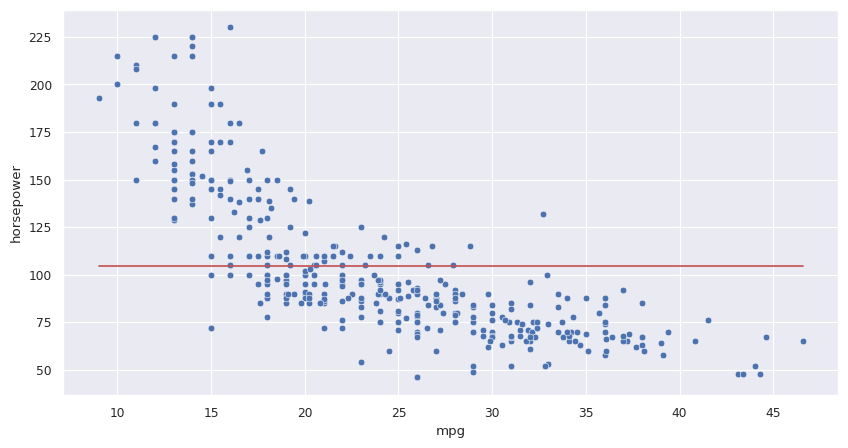

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x=x, y=y, ax=ax)
plt.plot(np.linspace(min(df[x]),max(df[x]),len(df[x])),np.array([np.mean(df[y])]*len(df[x])),'r')

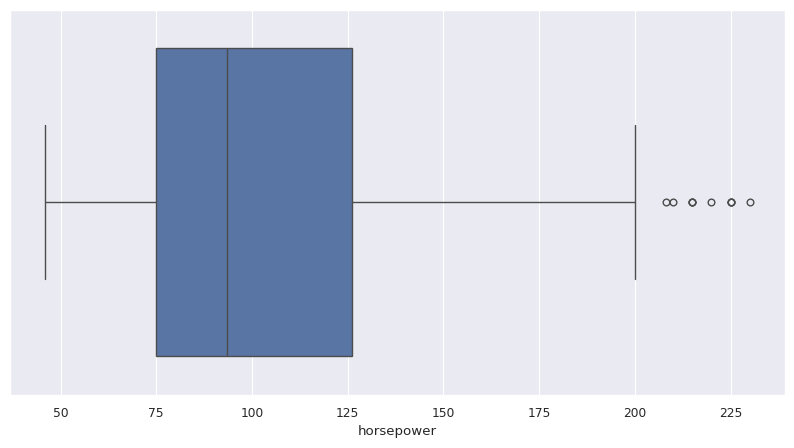

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='horsepower', ax=ax);

Puedo concluir que en general los carros tienen una potencia de 94.8hp y rendimiento de millas por galon de gasolina de 23.5 ademas los valores de potencia tipicos son de entre 50 y 200hp para carros comeciales desde 1982 al 1970.

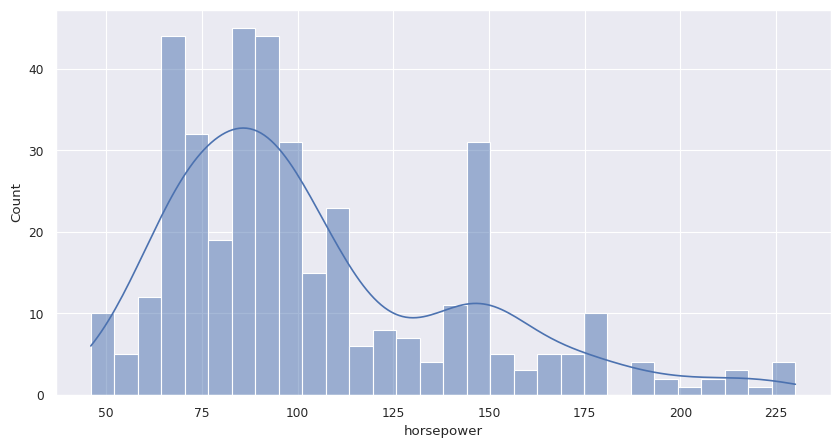

In [ ]:
# Gráfico de histograma con KDE
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x=y, bins=30, ax=ax, kde=True);

Podemos ver que hay dos picos en el ajuste a la distribucion de probabilidad lo cual indica que los datos son una combinacion de diferentes tipos de viculos comos caminomes, carros falmiliares, deportivos y de confort. Para los cuales cada uno tiene su propia preferencia al tipo de potencia que maneja normalmente. Lo que se ve reflejo como picos en la frecuencia.

In [ ]:
low = df["horsepower"] < 75
mid = (df["horsepower"] >= 75) & (df["horsepower"] < 125)
high = (df["horsepower"] >= 125) & (df["horsepower"] < 200)

In [ ]:
print(f'{np.mean(df[x][mid])},{np.mean(df[x][high])},{np.mean(df[x][low])}')

23.888349514563107,15.143333333333333,32.563529411764705


Podemos separar nuestros datos en tres grupos respecto a su potencia. Los que estan menorea a 75hp los que denominaremos de baja potencia, los que estan entre 75 a 125hp de media potencia y los mayores de 125hp de alta potencia.
Los 3 grupos respecto a la eficiencia de millas por galos se tiene que los que mejor rendimiento dan son los de baja potencia con un promedio de 32.6 millas por galon depues siguen los de media potencia que son los mas comunes en la poblacion con 23.9 millas por galon y los de alta potencia tienen la menor eficiencia con 14.9 millas por galon.

# Intento de modelación de los datos directamente

In [ ]:
def model_exp_offset(x, A, B, C):
    return A*np.exp(-B*x) + C

def model_power(x, A, B):
    return A * x**(-B)

def model_rational(x, A, B):
    return A/x + B

In [ ]:
from scipy.optimize import curve_fit
import numpy as np

x_vals = df[x].values
y_vals = df[y].values

params_exp, _ = curve_fit(model_exp_offset, x_vals, y_vals)
params_pow, _ = curve_fit(model_power, x_vals, y_vals)
params_rat, _ = curve_fit(model_rational, x_vals, y_vals)

/tmp/ipykernel_686/3773760157.py:2: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x) + C
/tmp/ipykernel_686/3773760157.py:2: RuntimeWarning: overflow encountered in multiply
  return A*np.exp(-B*x) + C


In [ ]:
y_exp = model_exp_offset(x_vals, *params_exp)
y_pow = model_power(x_vals, *params_pow)
y_rat = model_rational(x_vals, *params_rat)

In [ ]:
res_exp = y_vals - y_exp
res_pow = y_vals - y_pow
res_rat = y_vals - y_rat

In [ ]:
x_line = np.linspace(min(x_vals), max(x_vals), 300)

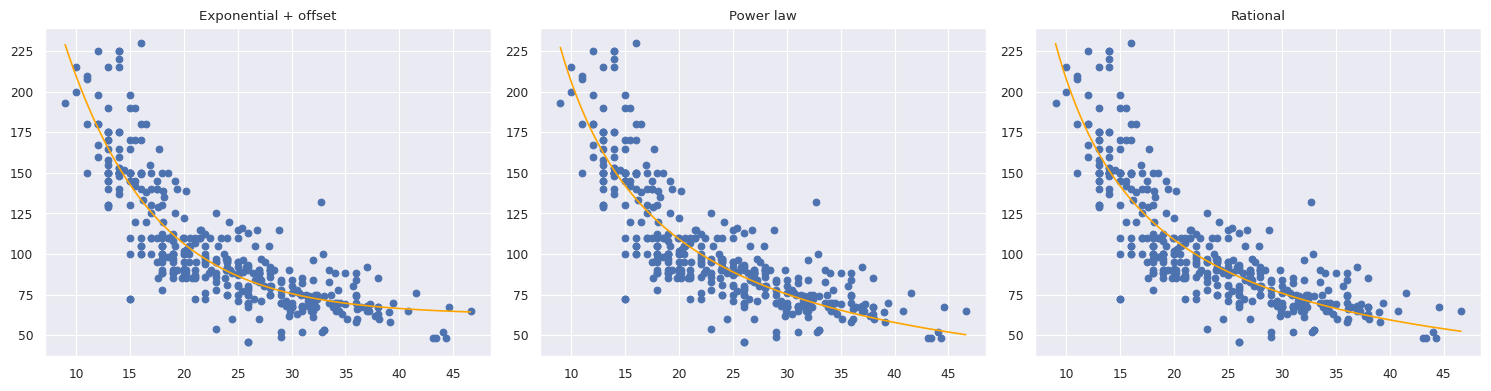

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(15,4))

# Exponential
ax[0].scatter(x_vals, y_vals)
ax[0].plot(x_line, model_exp_offset(x_line,*params_exp), color='orange')
ax[0].set_title("Exponential + offset")

# Power law
ax[1].scatter(x_vals, y_vals)
ax[1].plot(x_line, model_power(x_line,*params_pow), color='orange')
ax[1].set_title("Power law")

# Rational
ax[2].scatter(x_vals, y_vals)
ax[2].plot(x_line, model_rational(x_line,*params_rat), color='orange')
ax[2].set_title("Rational")

plt.tight_layout()
plt.show()

En las graficas anteriores tratamos de acomodar una funcion a la distribucion de los datos. Probamos con $\frac{B}{x}+A$ , $A e^{-B}$ y $A x^{-B}$

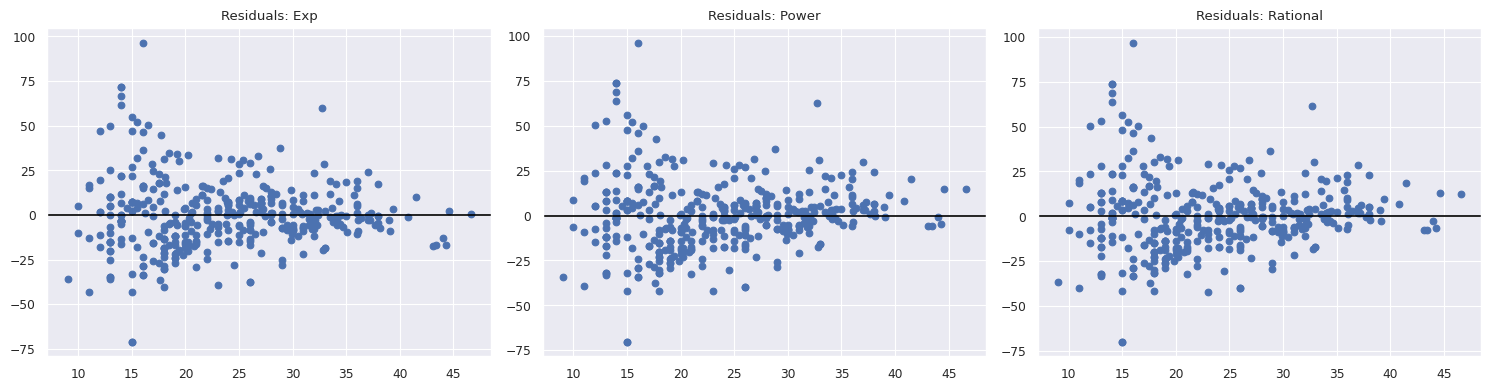

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

ax[0].scatter(x_vals, res_exp)
ax[0].axhline(0,color='black')
ax[0].set_title("Residuals: Exp")

ax[1].scatter(x_vals, res_pow)
ax[1].axhline(0,color='black')
ax[1].set_title("Residuals: Power")

ax[2].scatter(x_vals, res_rat)
ax[2].axhline(0,color='black')
ax[2].set_title("Residuals: Rational")

plt.tight_layout()
plt.show()

Para tratar de mirar que tambien se acomodan las funciones con la distribucion de datos, grafique la distribucion de los residuos. Podemos ver en la grafica que los residuos no si muestran una distribucion alrededor del zero y siguen un comportamiento aleatorio, pero no se distribuyen de forma uniforme con respecto al eje x. Por que no podemos concluir que los datos tienen el comportamiento de ninguna de las funciones, con este metodo.

In [ ]:
import numpy as np

def compute_stats(y, y_fit, p, sigma=None, mode="auto"):
    residuals = y - y_fit
    N = len(y)

    # --- R^2 ---
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    R2 = 1 - ss_res / ss_tot

    # --- Define sigma ---
    if sigma is not None:
        sigma_i = sigma

    elif mode == "auto":
        # estimate from residuals (global noise level)
        sigma_i = np.std(residuals)

    elif mode == "relative":
        # assume noise proportional to y (heteroscedastic)
        sigma_i = np.abs(y)

    else:
        raise ValueError("Invalid mode")

    # Avoid division by zero
    sigma_i = np.where(sigma_i == 0, 1e-8, sigma_i)

    # --- Chi-square ---
    chi2 = np.sum((residuals / sigma_i)**2)

    # --- Reduced chi-square ---
    chi2_red = chi2 / (N - p)

    return R2, chi2, chi2_red

In [ ]:
R2_exp, chi2_exp, chi2r_exp = compute_stats(y_vals, y_exp, 3)
R2_pow, chi2_pow, chi2r_pow = compute_stats(y_vals, y_pow, 2)
R2_rat, chi2_rat, chi2r_rat = compute_stats(y_vals, y_rat, 2)

In [ ]:
print("Model Comparison\n")

print("Exponential + Offset Model")
print(f"R^2           = {R2_exp:.4f}")
print(f"Chi-square    = {chi2_exp:.2f}")
print(f"Reduced Chi^2 = {chi2r_exp:.2f}")

print("\nPower Law Model")
print(f"R^2           = {R2_pow:.4f}")
print(f"Chi-square    = {chi2_pow:.2f}")
print(f"Reduced Chi^2 = {chi2r_pow:.2f}")

print("\nRational Model")
print(f"R^2           = {R2_rat:.4f}")
print(f"Chi-square    = {chi2_rat:.2f}")
print(f"Reduced Chi^2 = {chi2r_rat:.2f}")

Model Comparison

Exponential + Offset Model
R^2           = 0.7380
Chi-square    = 392.00
Reduced Chi^2 = 1.01

Power Law Model
R^2           = 0.7292
Chi-square    = 392.02
Reduced Chi^2 = 1.01

Rational Model
R^2           = 0.7307
Chi-square    = 392.00
Reduced Chi^2 = 1.01


Trate de evaluar la calidad de los modelos mediante los estadísticos $R^2$, $\chi^2$ y $\chi^2_{\text{reducida}}$. Inicialmente, solo los valores de $R^2$ parecían tener sentido, ya que indicaban que el modelo exponencial proporcionaba el mejor ajuste relativo entre los considerados.

Sin embargo, es importante notar que $R^2$ únicamente mide qué tan bien la función reproduce la variabilidad de los datos, es decir, qué fracción de la varianza es explicada por el modelo. No proporciona información directa sobre la validez física del modelo ni sobre la relación funcional real entre las variables (por ejemplo, cómo depende la potencia del sistema de la variable independiente).

Por otro lado, al corregir el cálculo de $\chi^2$ incorporando un modelo adecuado para las incertidumbres, se obtiene que $\chi^2_{\text{reducida}} \approx 1$ para todos los modelos. Esto indica que los tres modelos son consistentes con el nivel de ruido de los datos y que ninguno puede ser descartado desde un punto de vista estadístico.

En consecuencia, aunque el modelo exponencial presenta el mayor valor de $R^2$, las diferencias con los otros modelos son pequeñas y no significativas. Por lo tanto no se puede concluir que modelo es el mejor, por este metodo.
